<a href="https://colab.research.google.com/github/Vlasovasona/ML-home-works/blob/main/%D0%93%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B9_%D1%81%D0%BF%D1%83%D1%81%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [ ]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [ ]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [ ]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        loss = np.mean((X.dot(w) - y) ** 2)  # находим средний лосс
        return loss

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return grad: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        error = X.dot(w) - y
        grad = 2 * X.T.dot(error) / l
        return grad

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [ ]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [ ]:
import copy

In [ ]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    iterations = []
    w = w_init.copy()

    for _ in range(0, n_iterations):
        grad = loss.calc_grad(X, y, w)
        w -= lr * grad
        iterations.append(w.copy())

    return iterations

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [ ]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [ ]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

155.2625821435192
0.8670644395649493


In [ ]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

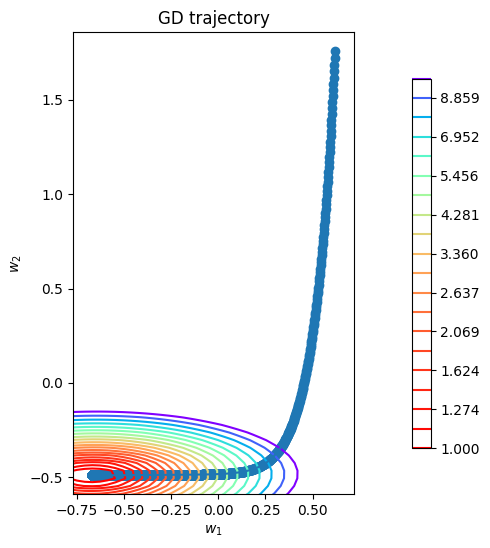

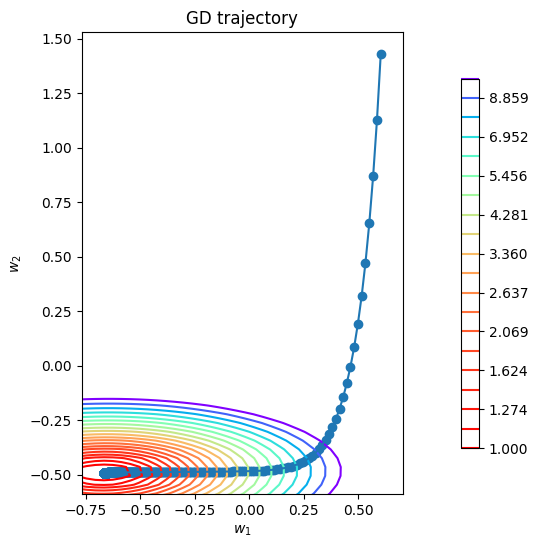

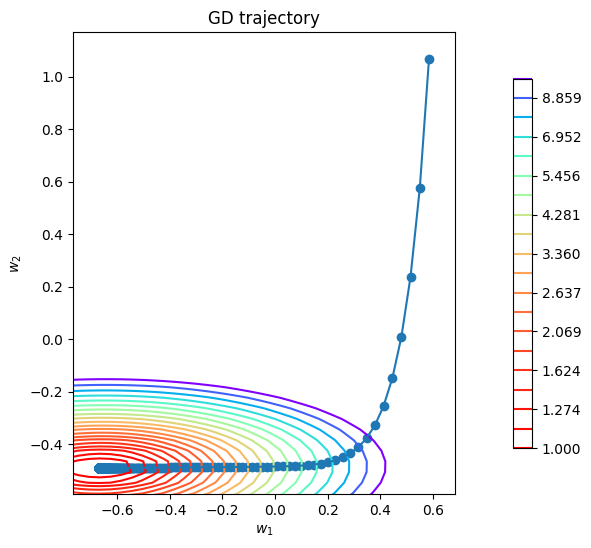

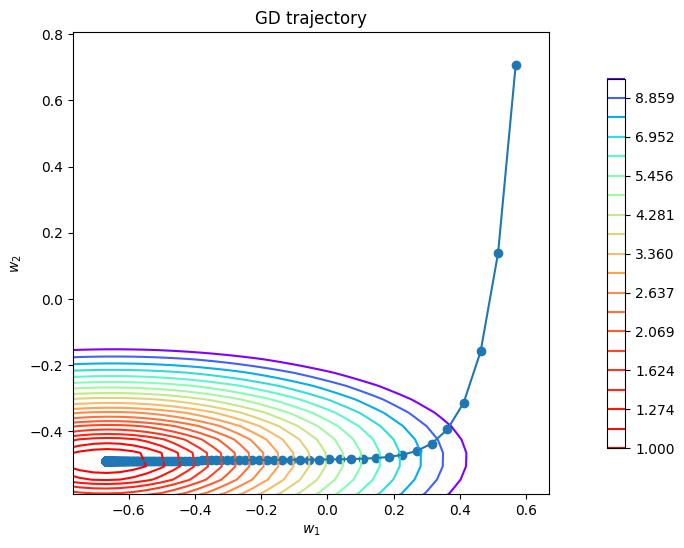

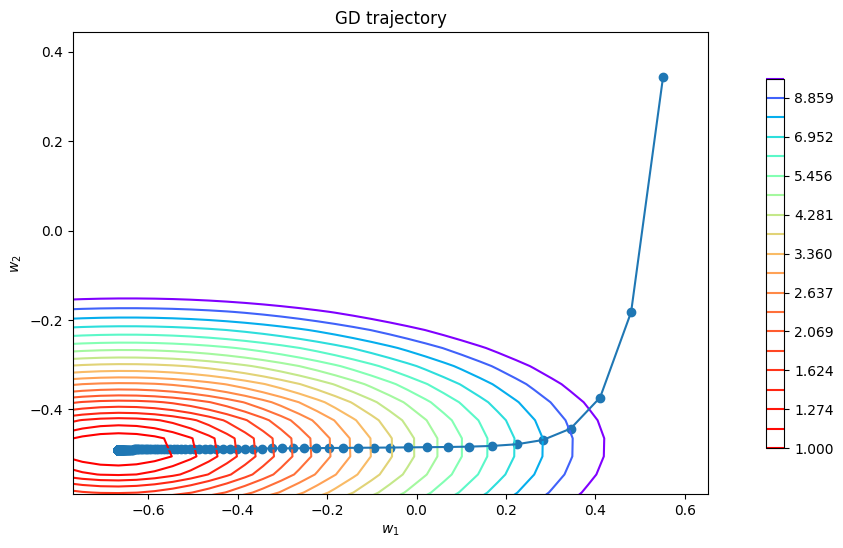

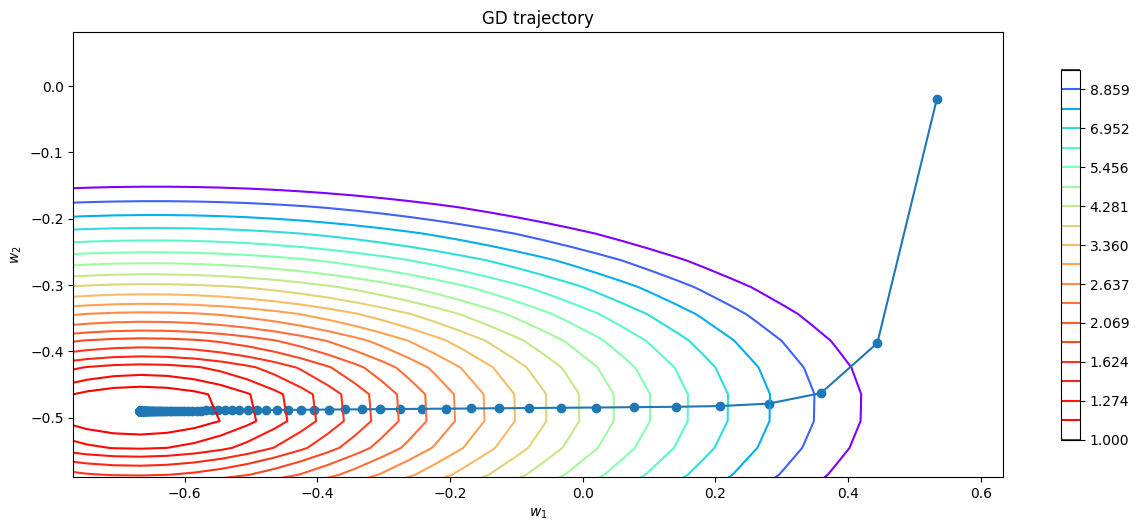

In [ ]:
lrs = [0.0001, 0.001, 0.002, 0.003, 0.004, 0.005]

for index, lr in enumerate(lrs):
  iterations = gradient_descent(w_init=w_init, X=X, y=y, loss=MSELoss(), lr=lr)
  plot_gd(w_list=iterations, X=X, y=y, loss=MSELoss())

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [ ]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    iterations = []  # Список для хранения истории весов
    w = w_init.copy()  # Копирование начальных весов

    indices = np.arange(len(y))

    for _ in range(0, n_iterations):
        random_indices = np.random.choice(indices, size=batch_size, replace=False)

        X_batch, y_batch = X[random_indices], y[random_indices]

        grad = loss.calc_grad(X_batch, y_batch, w)
        w -= lr * grad
        iterations.append(w.copy())

    return iterations

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

lr=0.0001 batch_size=30


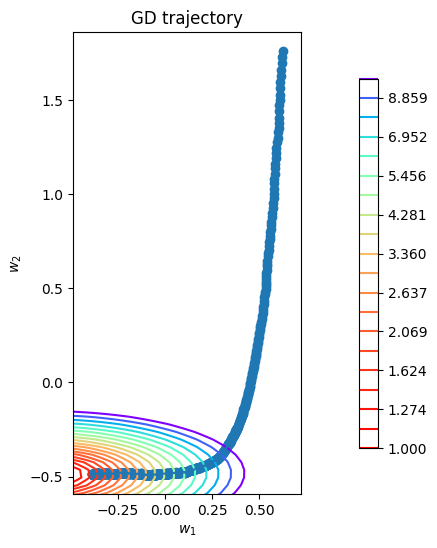

lr=0.0001 batch_size=60


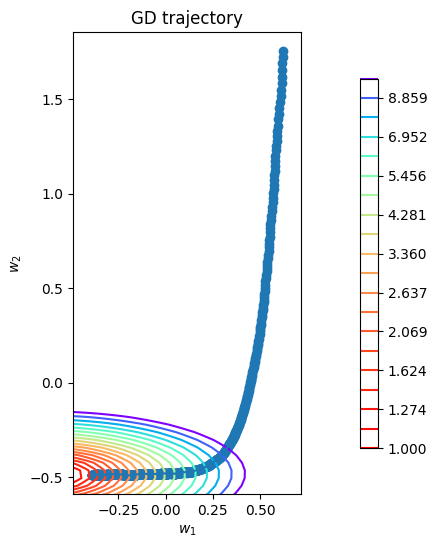

lr=0.0001 batch_size=150


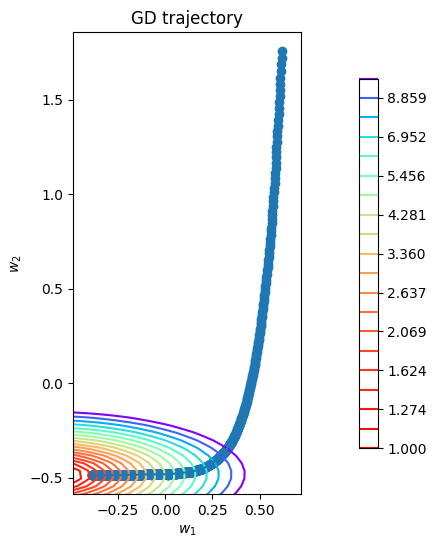

lr=0.0001 batch_size=300


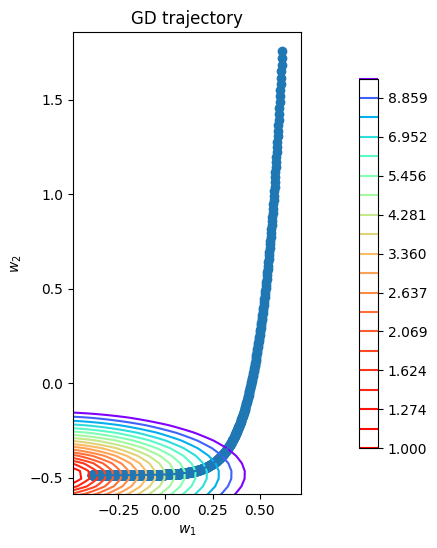

lr=0.001 batch_size=30


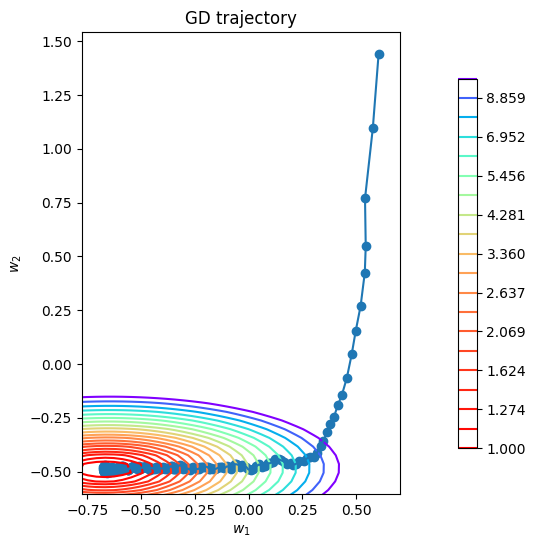

lr=0.001 batch_size=60


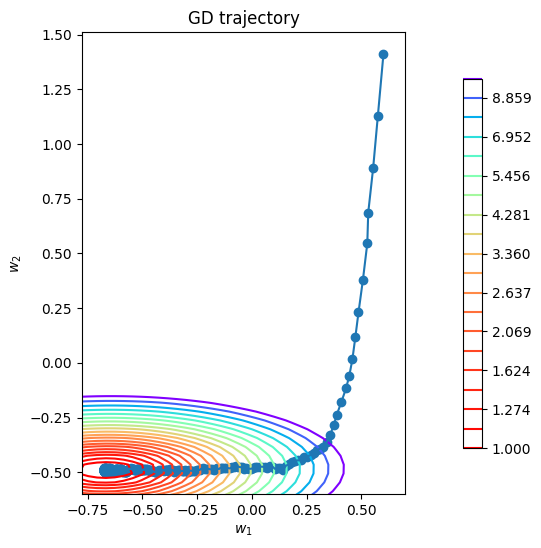

lr=0.001 batch_size=150


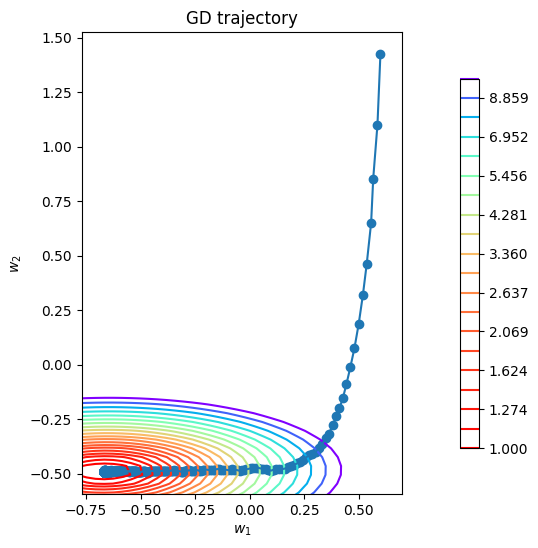

lr=0.001 batch_size=300


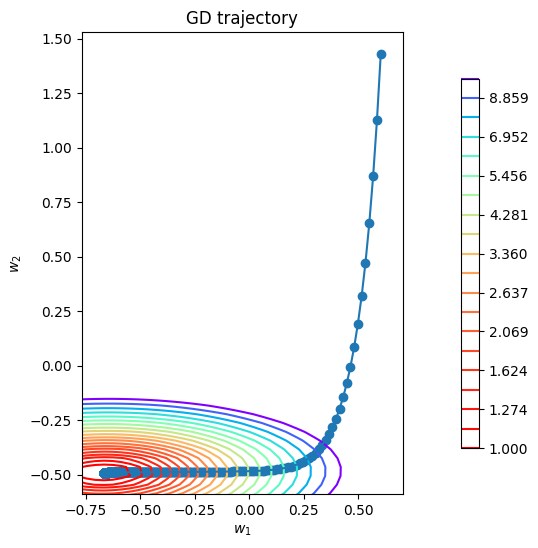

lr=0.002 batch_size=30


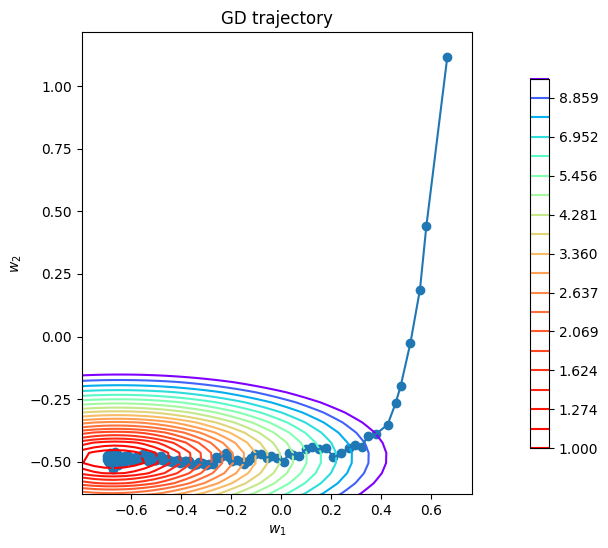

lr=0.002 batch_size=60


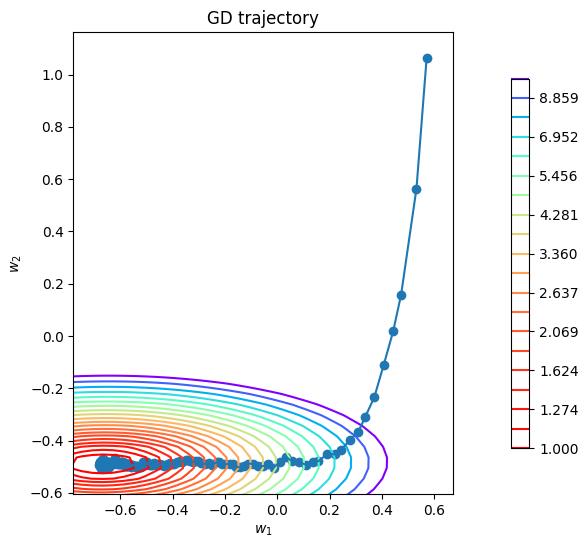

lr=0.002 batch_size=150


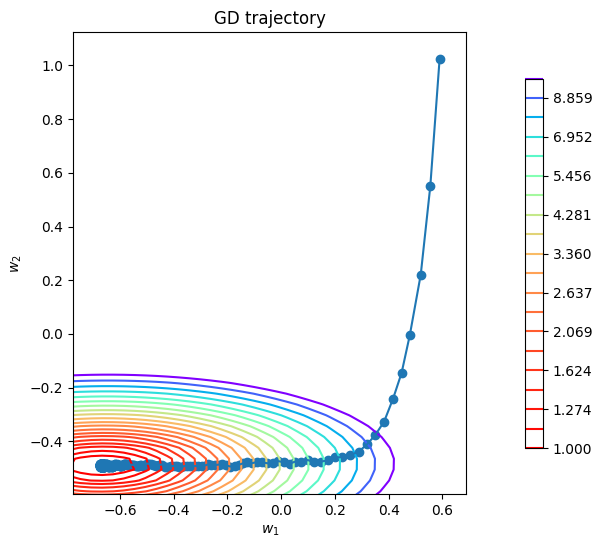

lr=0.002 batch_size=300


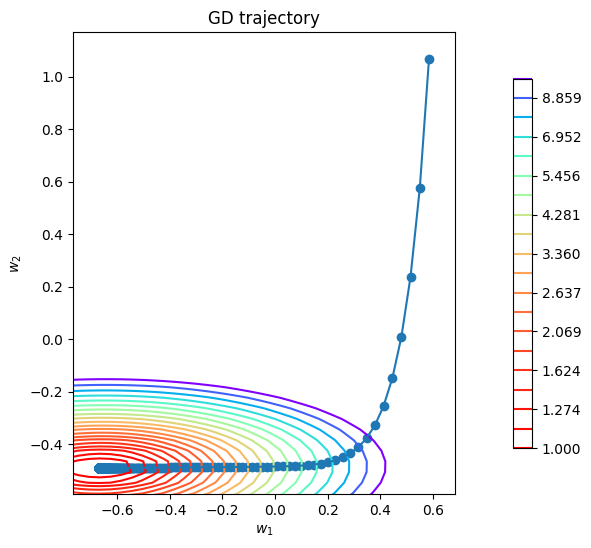

lr=0.004 batch_size=30


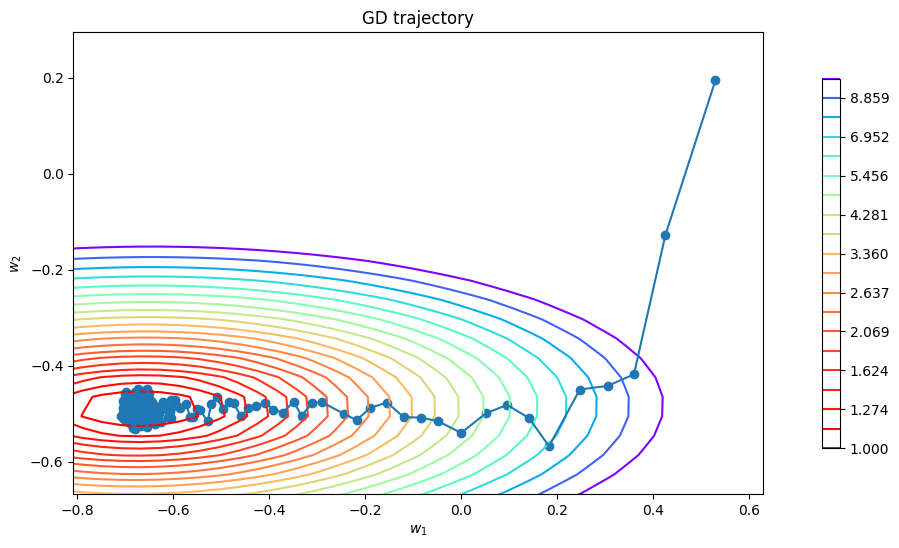

lr=0.004 batch_size=60


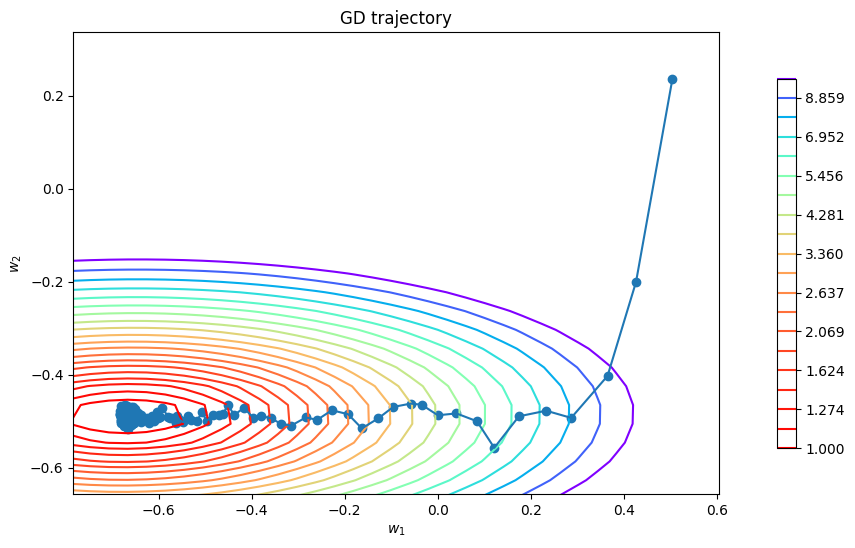

lr=0.004 batch_size=150


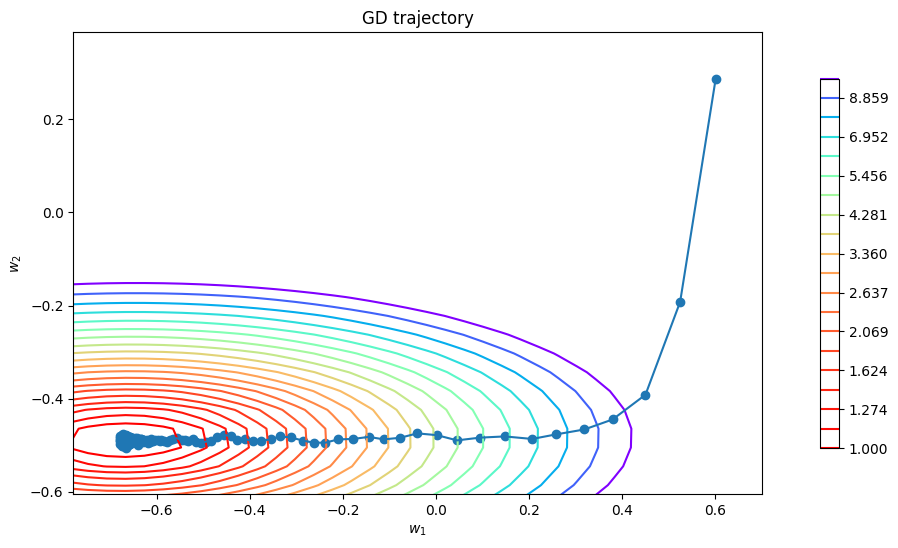

lr=0.004 batch_size=300


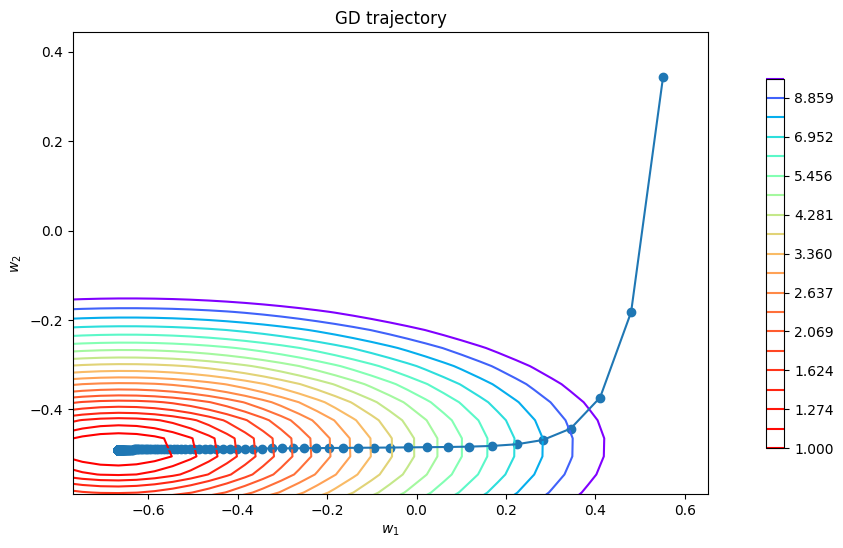

lr=0.005 batch_size=30


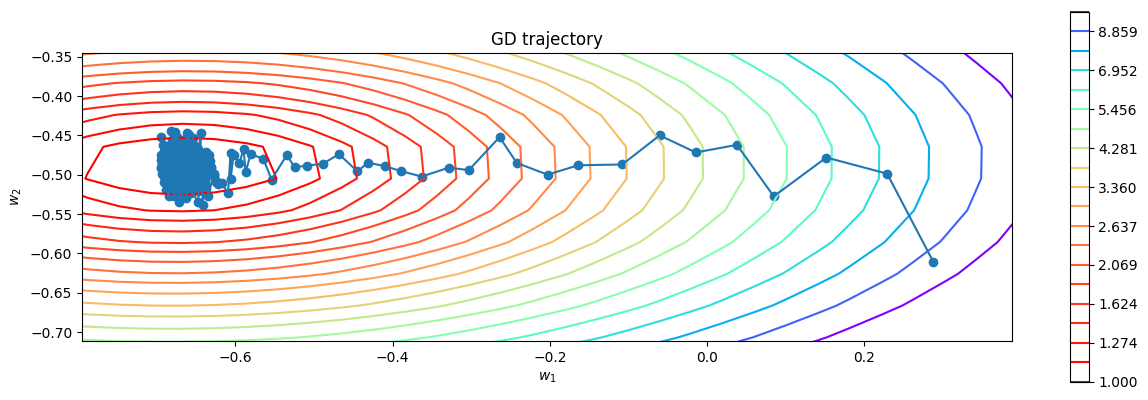

lr=0.005 batch_size=60


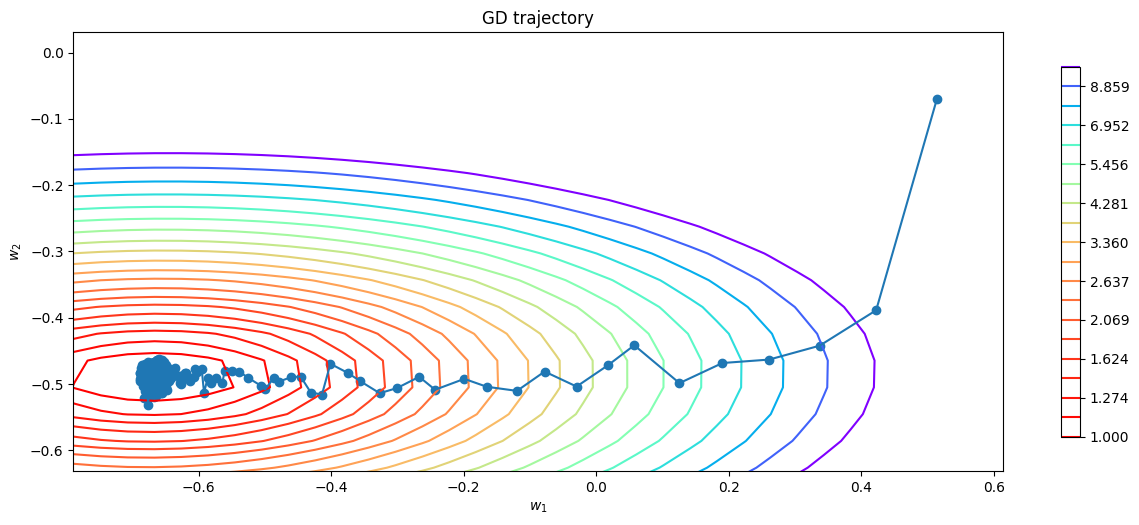

lr=0.005 batch_size=150


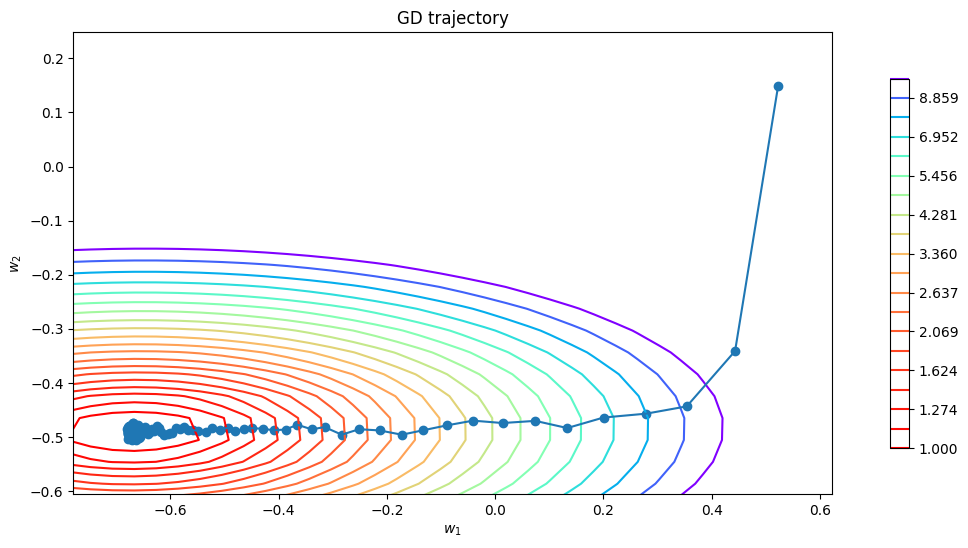

lr=0.005 batch_size=300


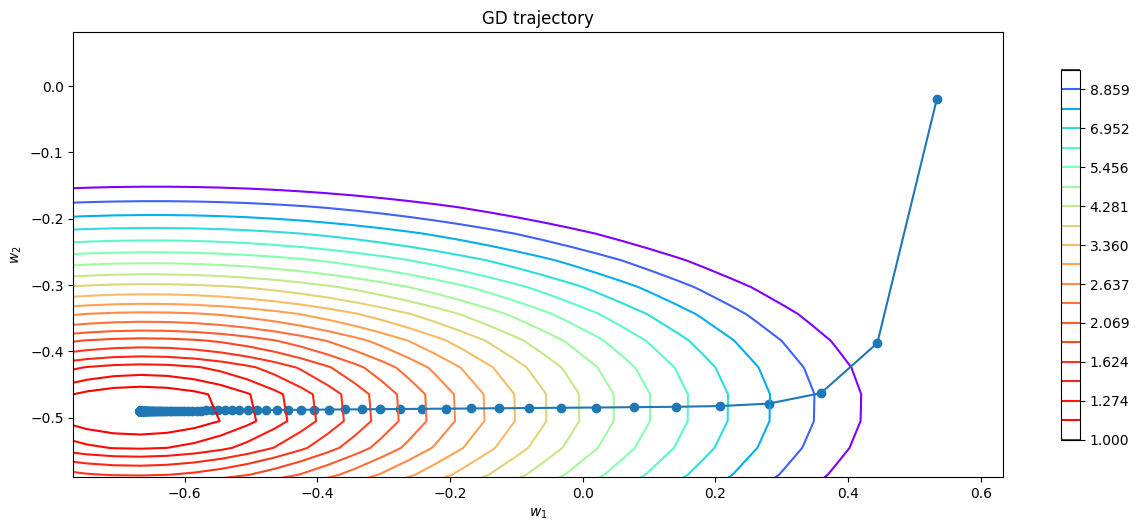

In [ ]:
lrs = [0.0001, 0.001, 0.002, 0.004, 0.005]
target_size = len(y)
batch_sizes = [target_size//10, target_size//5, target_size//2, target_size]

for i, lr in enumerate(lrs):
    for j, batch_size in enumerate(batch_sizes):
        print(f"lr={lr} batch_size={batch_size}")
        iterations = stochastic_gradient_descent(w_init=w_init, X=X, y=y, loss=MSELoss(), lr=lr, batch_size=batch_size)
        plot_gd(w_list=iterations, X=X, y=y, loss=MSELoss())



---


Сделайте и опишите свои выводы о том, как параметры lr и batch_size влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших batch_size?


---

1. Чем меньше длина шага, тем плавнее получается спуск (большее количество итераций требуется). Чем меньше batch_size, тем более шумной получается кривая (скорее всего связано с тем, что мы все время рассматриваем одни и те же объекты выборки, повторения встречаются чаще).

2. Стохастический градиентаный спуск менее затратный по времени, так как нам не нужно вычислять градиент по всем объектам, мы берем только один случайный. К тому же, стохастический градиентный спуск более шумный, это тоже связано с тем, что мы не считаем полный градиент по всем объектам.

3. **Про batch_size.** Если размер батча маленький, то можно наблюдать более шумное обучение (особенно это видно в конце спуска, там, где батч минимальный, зашумленность очень большая) и медленное схождение к минимуму (гипотетически может застрять даже в локальном минимуме, вероятность, скорее всего выше). Если батч равен размеру выборки (большой), то спуск менее шумный, времени затрачивается больше, но он более гарантировано найдет минимум функции.



---



Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [ ]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    iterations = []  # Список для хранения истории весов
    w = w_init.copy()  # Копирование начальных весов

    indices = np.arange(len(y))

    for iteration in range(0, n_iterations):
        length = lr * (1 / (1 + iteration))**p
        random_indices = np.random.choice(indices, size=batch_size, replace=False)

        X_batch, y_batch = X[random_indices], y[random_indices]

        grad = loss.calc_grad(X_batch, y_batch, w)
        w -= length * grad
        iterations.append(w.copy())

    return iterations

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

p=0.01


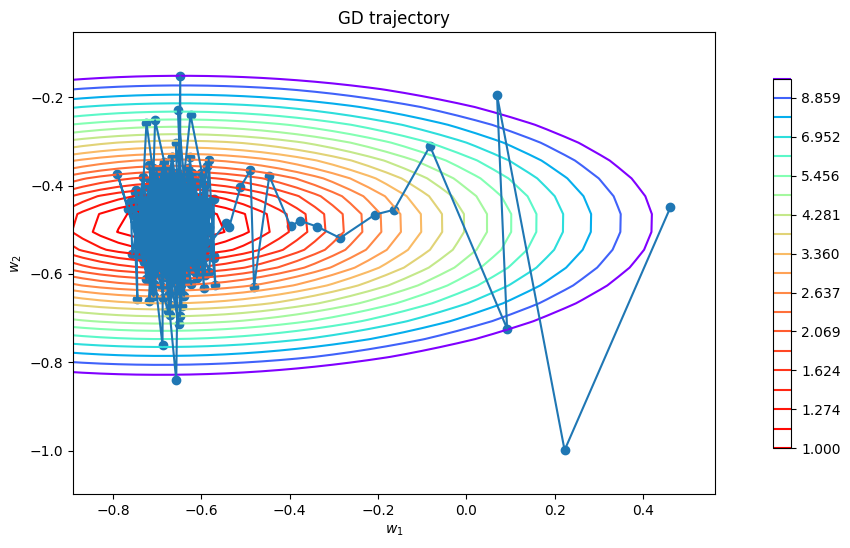

p=0.05


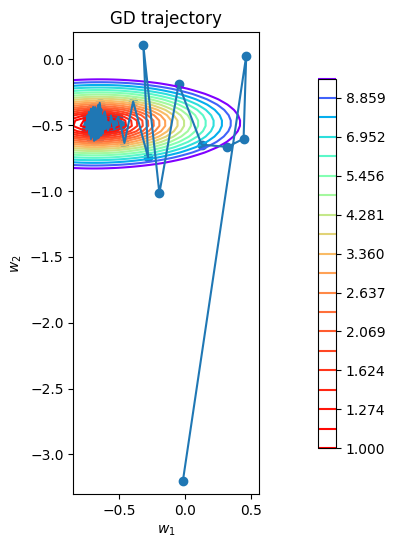

p=0.1


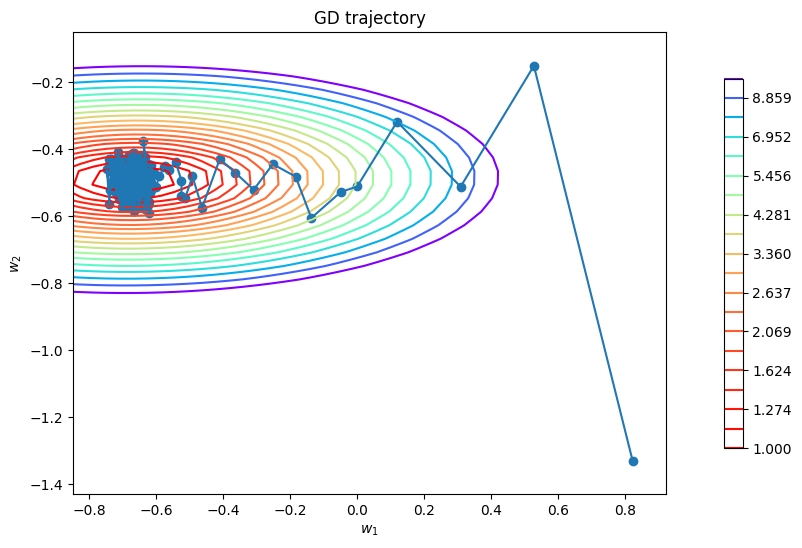

p=0.5


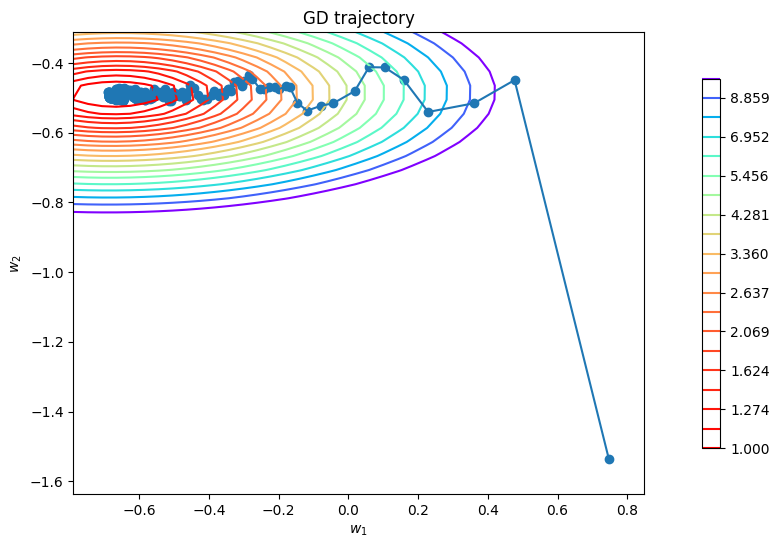

p=1


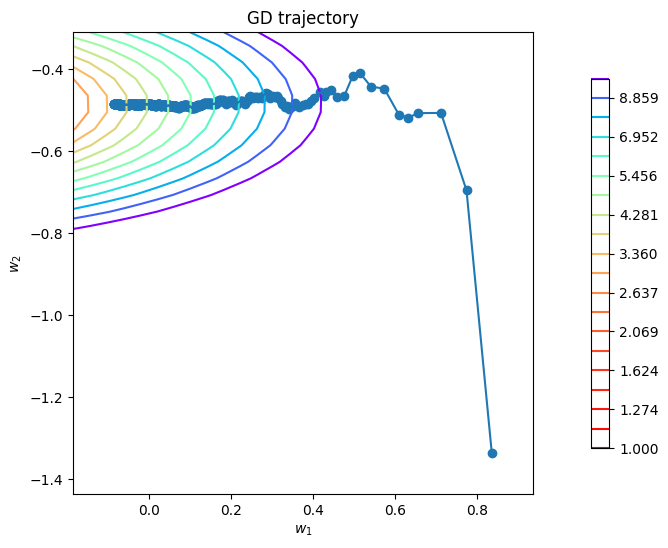

In [ ]:
p_values = [0.01, 0.05, 0.1, 0.5, 1]

for i, p in enumerate(p_values):
    print(f"p={p}")
    iterations = stochastic_gradient_descent(w_init=w_init, X=X, y=y, loss=MSELoss(), lr=0.01, batch_size=10, p=p)
    plot_gd(w_list=iterations, X=X, y=y, loss=MSELoss())



---

При малом p траектория более резкая, шаги более длинные. При p = 1 шаги меньше, траектория плавнее.
Это можно предположить даже просто исходя из формулы.


---



**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

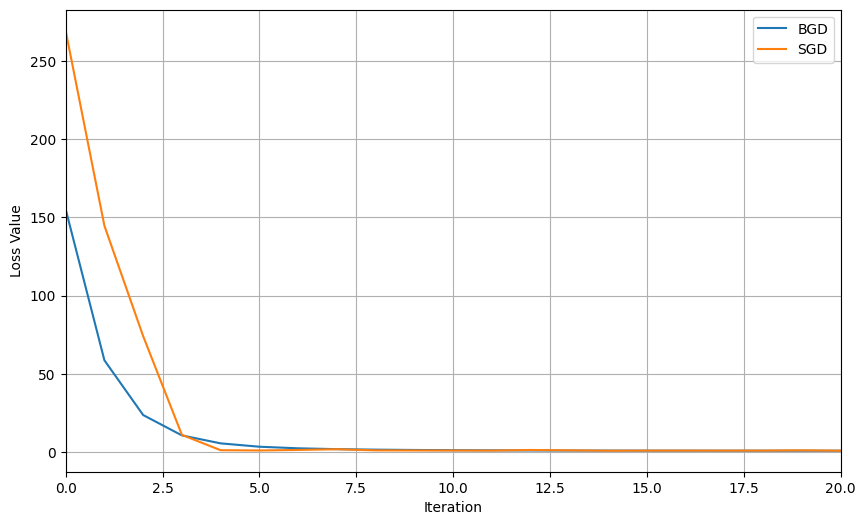

In [ ]:
gd = gradient_descent(w_init=w_init, X=X, y=y, loss=MSELoss(), lr=0.01)
gd_losses = np.array([loss.calc_loss(X, y, w) for w in gd])

# Стохастический градиентный спуск
sgd = stochastic_gradient_descent(w_init=w_init, X=X, y=y, loss=MSELoss(), lr=0.01, batch_size=10, p=0.1)
sgd_losses = np.array([loss.calc_loss(X, y, w) for w in sgd])

# Построение графиков
plt.figure(figsize=(10, 6))
plt.plot(np.arange(gd_losses.shape[0]), gd_losses, label='BGD')
plt.plot(np.arange(sgd_losses.shape[0]), sgd_losses, label='SGD')
plt.xlabel('Iteration')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.xlim(0, 20)
plt.show()



---

У SGD более рваная траектория и минимум достигается быстрее засчет меньшего количества итераций и увеличенного шага.
BGD более плавный, минимум достигается за большее количество шагов, так как их длина равна.


---



## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [ ]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        initial_w = np.random.randn(X.shape[1])
        iterations = gradient_descent(initial_w, X, y, self.loss, self.lr)
        self.w = iterations[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        predictions = X.dot(self.w)
        return predictions

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [ ]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [ ]:
import pandas as pd

url = 'https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw05_gd/cars_data.csv'
X_raw = pd.read_csv(
    url,
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)

X_raw = X_raw[~X_raw[25].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [ ]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

In [ ]:
y.shape

(205,)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer

In [ ]:
# заполнияю пропуски модой (так как медиана в случае большого количества выбросов нам бы не подошла)
cat_features_mask = (X_raw.dtypes == "object").values

X_real = X_raw[X_raw.columns[~cat_features_mask]]
mis_replacer = SimpleImputer(strategy="most_frequent")
X_no_mis_real = pd.DataFrame(
    data=mis_replacer.fit_transform(X_real), columns=X_real.columns
)
X_cat = X_raw[X_raw.columns[cat_features_mask]]
mode = X_cat.mode().iloc[0]
X_mode = X_cat.fillna(mode)
X_no_mis = pd.concat([X_no_mis_real, X_mode], axis=1)

y = y.fillna(y.mode()[0])

In [ ]:
X_no_mis.shape

(205, 25)

In [ ]:
y.isna().sum()

np.int64(0)

In [ ]:
X_no_mis.isna().sum()

,0
1,0
2,0
10,0
11,0
12,0
13,0
14,0
17,0
19,0
20,0


In [ ]:
unique_values = X_no_mis[6].unique()
unique_values

array(['two', 'four'], dtype=object)

In [ ]:
unique_values = X_no_mis[16].unique()
unique_values

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

Закодируем категориальные признаки 6 и 16 при помощи OrdinalEncoder, так как они являются ранговыми (погрядковыми) и OrdinalEncoder очень подходит для такого случая.


In [ ]:
# кодировка категориальных переменных
order = ['two', 'four']
enc = OrdinalEncoder(categories=[order])

X_no_mis[6] = enc.fit_transform(X_no_mis[6].values.reshape(-1, 1))

order = ['four', 'six', 'five', 'three', 'twelve', 'two', 'eight']
enc = OrdinalEncoder(categories=[order])

X_no_mis[16] = enc.fit_transform(X_no_mis[16].values.reshape(-1, 1))

In [ ]:
unique_values = X_no_mis[6].unique()
unique_values

array([0., 1.])

In [ ]:
X_no_mis.shape

(205, 25)

In [ ]:
X_no_mis.head()

,1,2,10,11,12,13,14,17,19,20,...,3,4,5,6,7,8,9,15,16,18
0,3.0,161.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,alfa-romero,gas,std,0.0,convertible,rwd,front,dohc,0.0,mpfi
1,3.0,161.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,alfa-romero,gas,std,0.0,convertible,rwd,front,dohc,0.0,mpfi
2,1.0,161.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,alfa-romero,gas,std,0.0,hatchback,rwd,front,ohcv,1.0,mpfi
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,...,audi,gas,std,1.0,sedan,fwd,front,ohc,0.0,mpfi
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,...,audi,gas,std,1.0,sedan,4wd,front,ohc,2.0,mpfi


In [ ]:
X_no_mis.columns = X_no_mis.columns.astype(str)

object_columns = X_no_mis.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_data = encoder.fit_transform(X_no_mis[object_columns])

encoded_ohe = pd.DataFrame(encoded_data,
                           columns=encoder.get_feature_names_out(object_columns))

index = X_no_mis.index
num_col = X_no_mis.select_dtypes(include=['int64', 'float']).columns.tolist()
X_numerical = X_no_mis[num_col]

final_df = pd.concat([X_numerical, encoded_ohe], axis=1)
final_df.index = index

In [ ]:
final_df.shape

(205, 60)

In [ ]:
# делим на тренировочную и тестовую
np.random.seed(51)
X_train, X_test, Y_train, Y_test = train_test_split(final_df,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=51)

In [ ]:
X_train.shape

(143, 60)

In [ ]:
Y_train.shape

(143,)

In [ ]:
# нормализация числовых признаков
normalizer = StandardScaler()
X_real_norm_np = normalizer.fit(X_train)
data_train = normalizer.transform(X_train)
data_test = normalizer.transform(X_test)
X_train = pd.DataFrame(data=data_train, columns=X_test.columns)
X_test = pd.DataFrame(data=data_test, columns=X_train.columns)

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [ ]:
regressor = LinearRegression(loss=MSELoss(), lr=0.01)
regressor.fit(X_train, Y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [ ]:
from sklearn.metrics import mean_squared_error

y_train_pred = regressor.predict(X_train)
y_test_pred = regressor.predict(X_test)

train_mse = mean_squared_error(Y_train, y_train_pred)
test_mse = mean_squared_error(Y_test, y_test_pred)

print(f"MSE на обучающей выборке: {train_mse}")
print(f"MSE на тестовой выборке: {test_mse}")

MSE на обучающей выборке: 2110499.4299833053
MSE на тестовой выборке: 11659194.947153682


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [ ]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        mse = np.mean((X.dot(w) - y) ** 2)
        l2 = self.coef * np.sum(w[:-1] ** 2) # тут убираю bias
        loss = mse + l2
        return loss

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        grad_without_reg = 2 * X.T.dot(X.dot(w) - y) / X.shape[0]
        grad_reg = 2 * self.coef * w
        grad = grad_without_reg + grad_reg
        grad[-1] = grad_without_reg[-1] # bias
        return grad

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [ ]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]

train = []
test = []

for alpha in alphas:
    linear_regression = LinearRegression(MSEL2Loss(alpha), lr=0.01)
    linear_regression.fit(X_train, Y_train)

    y_train_predict = linear_regression.predict(X_train)
    y_test_predict = linear_regression.predict(X_test)

    train_mse = mean_squared_error(Y_train, y_train_predict)
    test_mse = mean_squared_error(Y_test, y_test_predict)

    print(f"Коэффициент регуляризации {alpha}")
    print(f"МSE на обучающем наборе: {train_mse}")
    print(f"МSE на тестовом наборе: {test_mse}\n")

Коэффициент регуляризации 0.0001
МSE на обучающем наборе: 2110884.2154766987
МSE на тестовом наборе: 11447703.750895495

Коэффициент регуляризации 0.001
МSE на обучающем наборе: 2134020.5865146914
МSE на тестовом наборе: 10105459.712689873

Коэффициент регуляризации 0.01
МSE на обучающем наборе: 2433432.240080411
МSE на тестовом наборе: 7597891.144293261

Коэффициент регуляризации 0.1
МSE на обучающем наборе: 3286100.9683626415
МSE на тестовом наборе: 6553017.195161445

Коэффициент регуляризации 1.0
МSE на обучающем наборе: 7679641.212315454
МSE на тестовом наборе: 7270443.794363487



Лучше всего подходит коэффициент **0.1**. Ошибка при 0.1 равна 6_553_017, тогда как без регуляризации она была равна 11_659_194.


---



В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [ ]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        z = X.dot(w) - y
        huber_loss = np.where(np.abs(z) < self.eps, 0.5 * z ** 2, self.eps * (np.abs(z) - 0.5 * self.eps))

        return np.mean(huber_loss)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        z = X.dot(w) - y
        fi = np.where(np.abs(z) < self.eps, z, self.eps * np.sign(z))
        grad = X.T.dot(fi) / X.shape[0]

        return grad

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [ ]:
linear_regression = LinearRegression(HuberLoss(1.0))

In [ ]:
alphas = [20.0, 25.0, 30.0, 35.0, 40.0, 45.0]

for alpha in alphas:
    linear_regression = LinearRegression(HuberLoss(alpha), lr=0.01)
    linear_regression.fit(X_train, Y_train)

    y_train_predict = linear_regression.predict(X_train)
    y_test_predict = linear_regression.predict(X_test)

    train_mse = mean_squared_error(Y_train, y_train_predict)
    test_mse = mean_squared_error(Y_test, y_test_predict)

    print(f"huber loss: {alpha}")
    print(f"МSE на обучающем наборе: {train_mse}")
    print(f"МSE на тестовом наборе: {test_mse}\n")

huber loss: 20.0
МSE на обучающем наборе: 7310914.305116845
МSE на тестовом наборе: 7416177.997573129

huber loss: 25.0
МSE на обучающем наборе: 5092580.566449117
МSE на тестовом наборе: 5891335.318877912

huber loss: 30.0
МSE на обучающем наборе: 4544255.576131705
МSE на тестовом наборе: 6013202.058806665

huber loss: 35.0
МSE на обучающем наборе: 4141666.2886117706
МSE на тестовом наборе: 6210617.025871282

huber loss: 40.0
МSE на обучающем наборе: 3858701.4165269495
МSE на тестовом наборе: 6531558.618106365

huber loss: 45.0
МSE на обучающем наборе: 3667768.4161357027
МSE на тестовом наборе: 6939859.166015098



Получилось так, что ошибка при использовании HuberLoss c парметром 25.0 равна 5_891_335, что меньше чем минимальная достигнутая ошибка при использовании MSE2Loss, и меньше чем при использовании стандартного MSE, что говорит о том, что выбросы в датасете есть, и мы смогли "нейтрализовать" их влияние при помощи huber loss.


---



**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

<a href="https://ibb.co/XfJJTxnk"><img src="https://i.ibb.co/xK55Qqn8/5190580093498551220-1.jpg" alt="5190580093498551220-1" border="0"></a>

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [ ]:
# -- YOUR CODE HERE -- ʕ•ᴥ•ʔ